## Import the Packages

In [1]:
from scipy.integrate import quad
import numpy as np
import matplotlib.pyplot as plt

## Define the parameter Space

### Set the range of z
$z\in(0.001,2)$

In [2]:
z_list = np.linspace(0.001,2,10000)

### Set the fixed values of the parameter (measured values)
$\Omega_m = 0.3$, $H_0=67$, $c=1$

In [3]:
O_m_fixed = 0.3
H0_fixed = 67
c = 1

### Specify the range of variation of $\Omega_m$ and $H_0$
$\Omega_m \in (0.1,0.9)$, $H_0 \in (60,80)$

In [4]:
O_m_list = np.linspace(0.1,0.9,5)
H0_list = np.linspace(60,80,5)

## The dimensionless Hubble function : E(Z)

### Define the function E(z)

$E(z) = \sqrt{\Omega_m (1+z)^3 + (1-\Omega_m)}$

In [5]:
def E(z):
    result = (O_m * ((1+z)**3)) + (1 - O_m)
    return result

### Plot $E(z)$ vs. $z$ with $\Omega_m=0.3$

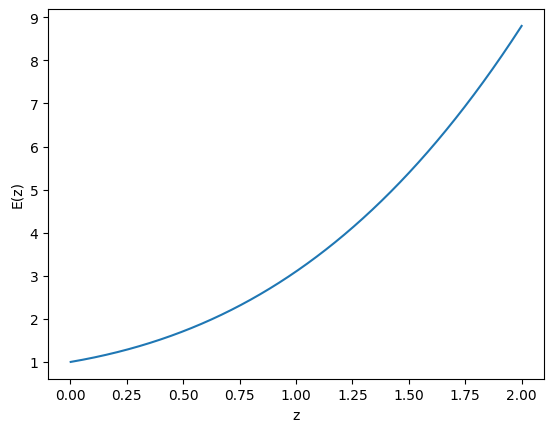

In [6]:
O_m = O_m_fixed
E_list = E(z_list)
plt.xlabel("z")
plt.ylabel("E(z)")
plt.plot(z_list,E_list)
plt.show()

### Plot $E(z)$ vs. $z$ with $\Omega_m \in (0.1,0.9)$

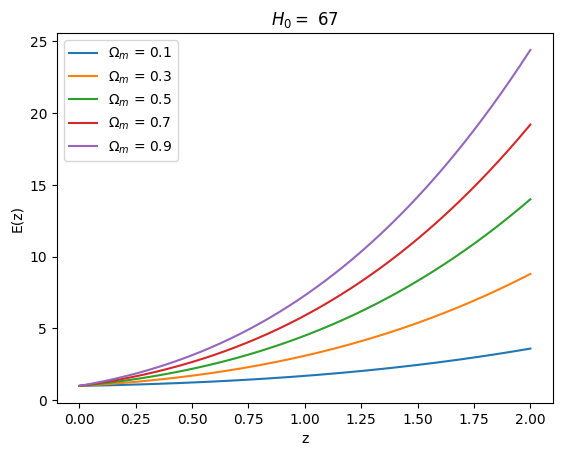

In [7]:
for O_m in O_m_list:
    E_diff_O_m_list = []
    H0 = H0_fixed
    for z in z_list:
        E_diff_O_m_list.append(E(z))
    plt.plot(z_list, E_diff_O_m_list,label=rf"$\Omega_m$ = {O_m:.1f}")
plt.legend()
plt.title(fr"$H_0=$ {H0}")
plt.xlabel("z")
plt.ylabel("E(z)")
plt.show()

## The luminosity distance : $d_L(z)$

### Define the function $d_L(z)$

In [8]:
def d_L(zf):
    # Increase the limit of subdivisions
    inte, error = quad(lambda z: 1/E(z), 0, zf, epsabs=1e-5, epsrel=1e-5)

    result = (1+zf) * (c / H0)* inte
    return result

### Plot $d_L(z)$ vs. $z$ with $\Omega_m = 0.3$ and $H_0 = 67$

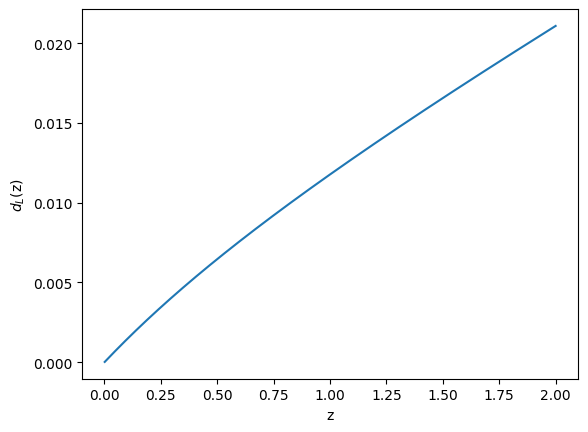

In [9]:
H0 = H0_fixed
dL_list = []
for z in z_list:
    dL_list.append(d_L(z))
dL_list = np.array(dL_list)
plt.xlabel("z")
plt.ylabel(r"$d_L$(z)")
plt.plot(z_list,dL_list)
plt.show()

### Plot $d_L(z)$ vs. $z$ with $\Omega_m=0.3$ and $H_0 \in (60,80)$

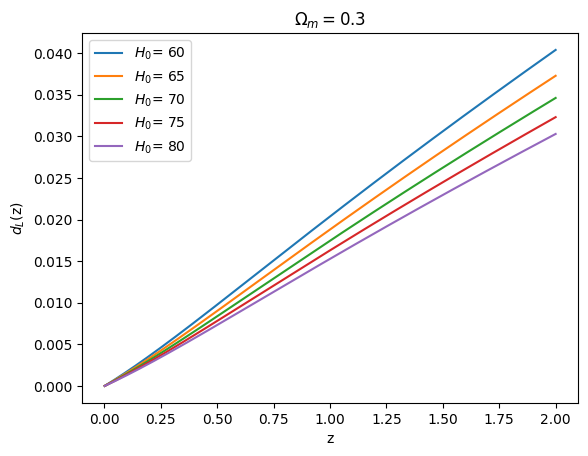

In [10]:
for H0 in H0_list:
    dL_diff_H_0_list = []
    O_m = O_m_fixed
    for z in z_list:
        dL_diff_H_0_list.append(d_L(z))
    plt.plot(z_list, dL_diff_H_0_list,label=rf"$H_0$= {H0:.0f}")
plt.legend()
plt.title(r"$\Omega_m=0.3$")
plt.xlabel("z")
plt.ylabel(r"$d_L$(z)")
plt.show()

### Plot $d_L(z)$ vs. $z$ with $\Omega_m \in (0.1,0.9)$ and $H_0 = 67$

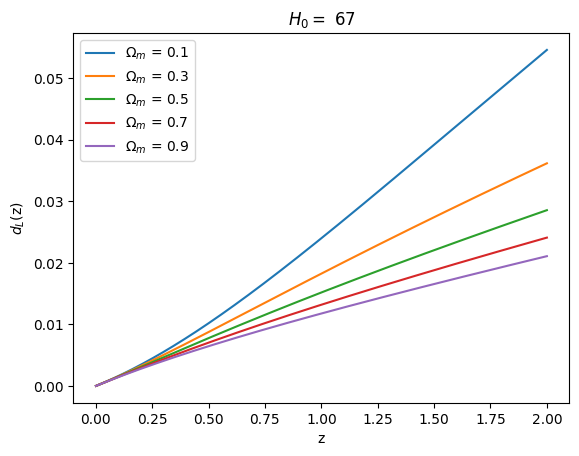

In [11]:
for O_m in O_m_list:
    dL_diff_O_m_list = []
    H0 = H0_fixed
    for z in z_list:
        dL_diff_O_m_list.append(d_L(z))
    plt.plot(z_list, dL_diff_O_m_list,label=rf"$\Omega_m$ = {O_m:.1f}")
plt.legend()
plt.title(fr"$H_0=$ {H0}")
plt.xlabel("z")
plt.ylabel(r"$d_L$(z)")
plt.show()

## The theoretical distance modulus : $\mu(z)$

### Define the function $\mu(z)$

In [12]:
def mu(z):
    result = (5*np.log10(d_L(z))) + 25
    return result

### Plot $\mu(z)$ vs. $z$ with $\Omega_m = 0.3$ and $H_0 = 67$

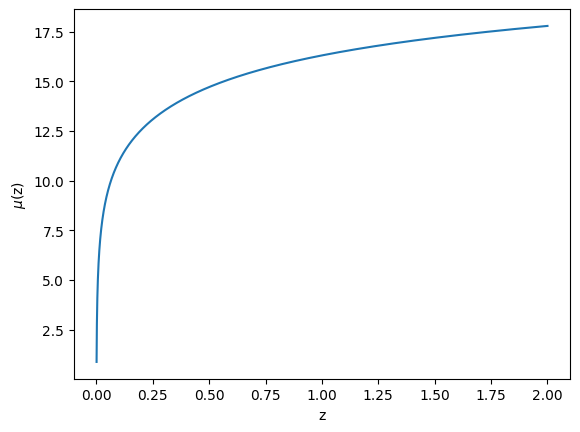

In [13]:
O_m = O_m_fixed
H0 = H0_fixed
mu_list = []
for z in z_list:
    mu_list.append(mu(z))
mu_list = np.array(mu_list)
plt.xlabel("z")
plt.ylabel(r"$\mu$(z)")
plt.plot(z_list,mu_list)
plt.show()

### Plot $\mu(z)$ vs. $z$ with $\Omega_m=0.3$ and $H_0 \in (60,80)$

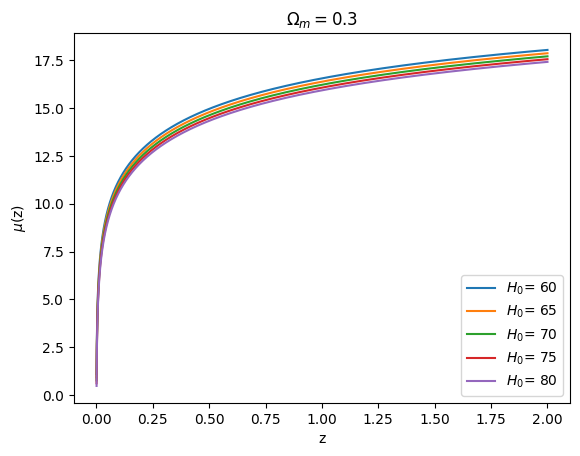

In [14]:
for H0 in H0_list:
    diff_H_0_list = []
    O_m = O_m_fixed
    for z in z_list:
        diff_H_0_list.append(mu(z))
    plt.plot(z_list, diff_H_0_list,label=rf"$H_0$= {H0:.0f}")
plt.legend()
plt.title(r"$\Omega_m=0.3$")
plt.xlabel("z")
plt.ylabel(r"$\mu$(z)")
plt.show()

### Plot $\mu(z)$ vs. $z$ with $\Omega_m \in (0.1,0.9)$ and $H_0 = 67$

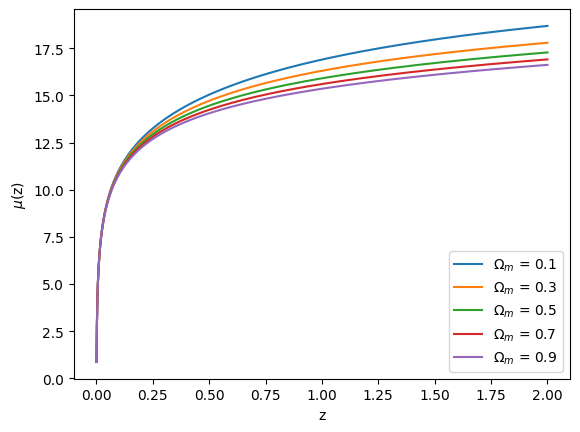

In [15]:
for O_m in O_m_list:
    diff_O_m_list = []
    H0 = H0_fixed
    for z in z_list:
        diff_O_m_list.append(mu(z))
    plt.plot(z_list, diff_O_m_list,label=rf"$\Omega_m$ = {O_m:.1f}")
plt.legend()
plt.xlabel("z")
plt.ylabel(r"$\mu$(z)")
plt.show()